# This notebook primarily explores the difference between linear and circular convolution for the L1 reconstruction, both the parallelized and serial implementations

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import helpers
import os
import logging, sys
import math
matplotlib.rcParams['figure.figsize'] = [10, 5]

cmap = "turbo"

breakdowns = [
    "read",
    "grid",
    "degrid",
    "deconvolve",
    "other"
]

breakdowns_parallel = [
    "read",
    "grid",
    "degrid",
    "deconvolve",
    "wait",
    "other"
]

num_mc_l1 = 5

def total_timings(timings, breakdowns):
    total = []
    
    for i, breakdown in enumerate(breakdowns):
        curr_timing = 0

        for timing in timings:
            curr_timing += timing[i]

        total.append(curr_timing)
        
    return total

pcols = ["forestgreen", "teal", "mediumblue", "blueviolet", "fuchsia"]

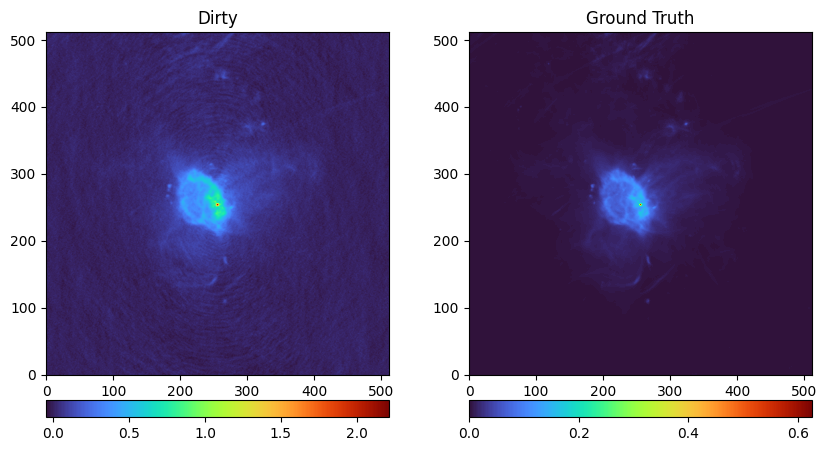

In [27]:
sgra_res_path = "../results/conv_results/SGRA/"

breakdown_data_lin = []
breakdown_data_circ = []

partitions=["<4", "2-11", "9-36", "34-71", ">69"]
num_partitions = len(partitions)

for i in range(num_partitions):
    breakdown_data_lin.append(helpers.read_csv(sgra_res_path + "multi_partition_sgra_pl1_linear/mc_timings_breakdown_" + str(i), separate_rows=True))
    breakdown_data_circ.append(helpers.read_csv(sgra_res_path + "multi_partition_sgra_pl1_circ/mc_timings_breakdown_" + str(i), separate_rows=True))
    
serial_breakdown_data_lin = helpers.read_csv(sgra_res_path + "multi_partition_sgra_seriall1_linear/mc_timings_breakdown", separate_rows=True)
serial_breakdown_data_circ = helpers.read_csv(sgra_res_path + "multi_partition_sgra_seriall1_circ/mc_timings_breakdown", separate_rows=True)

gt = helpers.readFits("../data7/SGRA_full_gt.fits")
dirty = helpers.readFits(sgra_res_path + "multi_partition_sgra_seriall1_linear/residual_0.fits")
helpers.plotNImages([dirty, gt], ["Dirty", "Ground Truth"], cmap="turbo")

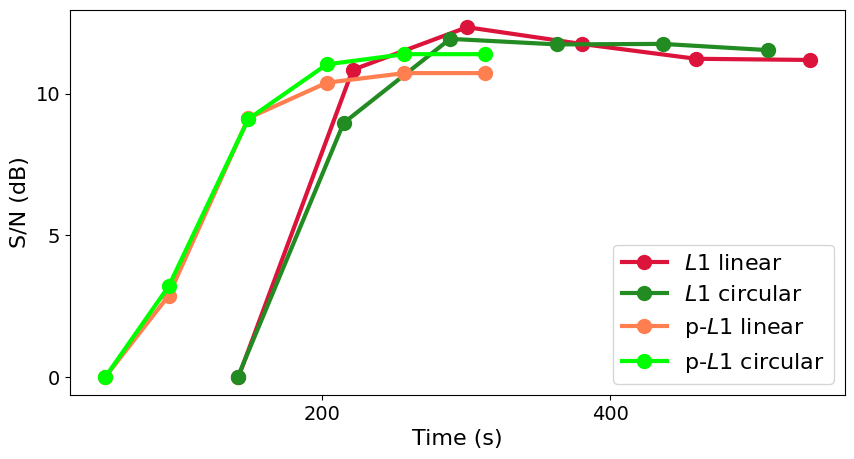

In [29]:
serial_times_lin = []
serial_snrs_lin = []
serial_times_circ = []
serial_snrs_circ = []

parallel_times_lin = []
parallel_snrs_lin = []
parallel_times_circ = []
parallel_snrs_circ = []

serial_lin_times_sep = helpers.read_csv(sgra_res_path + "multi_partition_sgra_seriall1_linear/mc_timings")
serial_circ_times_sep = helpers.read_csv(sgra_res_path + "multi_partition_sgra_seriall1_circ/mc_timings")
parallel_lin_times_sep = helpers.read_csv(sgra_res_path + "multi_partition_sgra_pl1_linear/mc_timings")
parallel_circ_times_sep = helpers.read_csv(sgra_res_path + "multi_partition_sgra_pl1_circ/mc_timings")

best_parallel_lin_recon = None
best_serial_lin_recon = None
best_parallel_circ_recon = None
best_serial_circ_recon = None

best_parallel_lin_snr = -9999
best_serial_lin_snr = -9999
best_parallel_circ_snr = -9999
best_serial_circ_snr = -9999


#serial linear
curr_deconv = None
time_acc = float(serial_lin_times_sep[0])
serial_times_lin.append(time_acc)
serial_snrs_lin.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = helpers.readFits(sgra_res_path + "multi_partition_sgra_seriall1_linear/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_lin_times_sep[i+1])
    
    serial_snrs_lin.append(helpers.compute_snr(curr_deconv, gt))
    serial_times_lin.append(time_acc)
    
    if best_serial_lin_snr < serial_snrs_lin[-1]:
        best_serial_lin_recon = curr_deconv.copy()
        best_serial_lin_snr = serial_snrs_lin[-1]
        

#serial circular

curr_deconv = None
time_acc = float(serial_circ_times_sep[0])
serial_times_circ.append(time_acc)
serial_snrs_circ.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = helpers.readFits(sgra_res_path + "multi_partition_sgra_seriall1_circ/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_circ_times_sep[i+1])
    
    serial_snrs_circ.append(helpers.compute_snr(curr_deconv, gt))
    serial_times_circ.append(time_acc)
    
    if best_serial_circ_snr < serial_snrs_circ[-1]:
        best_serial_circ_recon = curr_deconv.copy()
        best_serial_circ_snr = serial_snrs_circ[-1]
    
    
#parallel linear
time_acc = float(parallel_lin_times_sep[0])
parallel_times_lin.append(time_acc)
parallel_snrs_lin.append(0)

for i in range(0, num_mc_l1):
    time_acc += float(parallel_lin_times_sep[i+1])

    curr_deconv_combined = helpers.readFits(sgra_res_path + "multi_partition_sgra_pl1_linear/recon_combined_" + str(i) + ".fits")
    parallel_snrs_lin.append(helpers.compute_snr(curr_deconv_combined, gt))
    
    parallel_times_lin.append(time_acc)
    
    if best_parallel_lin_snr < parallel_snrs_lin[-1]:
        best_parallel_lin_recon = curr_deconv_combined.copy()
        best_parallel_lin_snr = parallel_snrs_lin[-1]
        
        
#parallel circular
time_acc = float(parallel_circ_times_sep[0])
parallel_times_circ.append(time_acc)
parallel_snrs_circ.append(0)

for i in range(0, num_mc_l1):
    time_acc += float(parallel_circ_times_sep[i+1])

    curr_deconv_combined = helpers.readFits(sgra_res_path + "multi_partition_sgra_pl1_circ/recon_combined_" + str(i) + ".fits")
    parallel_snrs_circ.append(helpers.compute_snr(curr_deconv_combined, gt))
    
    parallel_times_circ.append(time_acc)
    
    if best_parallel_circ_snr < parallel_snrs_circ[-1]:
        best_parallel_circ_recon = curr_deconv_combined.copy()
        best_parallel_circ_snr = parallel_snrs_circ[-1]

        
plt.plot(serial_times_lin, serial_snrs_lin, c='crimson', label="$L1$ linear", lw=3, marker='o', markersize=10)
plt.plot(serial_times_circ, serial_snrs_circ, c='forestgreen', label="$L1$ circular", lw=3, marker='o', markersize=10)
plt.plot(parallel_times_lin, parallel_snrs_lin, c='coral', label="p-$L1$ linear", lw=3, marker='o', markersize=10)
plt.plot(parallel_times_lin, parallel_snrs_circ, c='lime', label="p-$L1$ circular", lw=3, marker='o', markersize=10)


plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

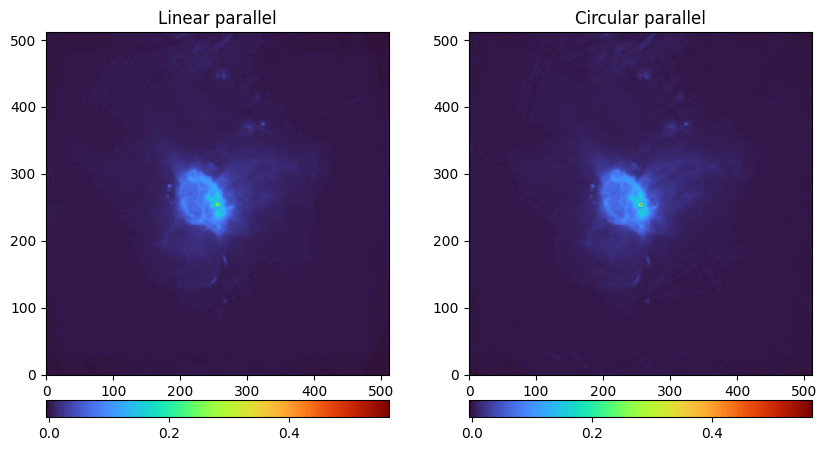

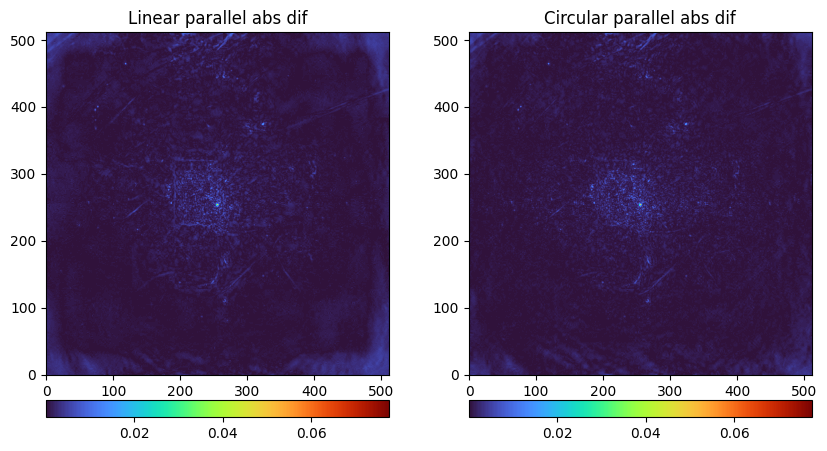

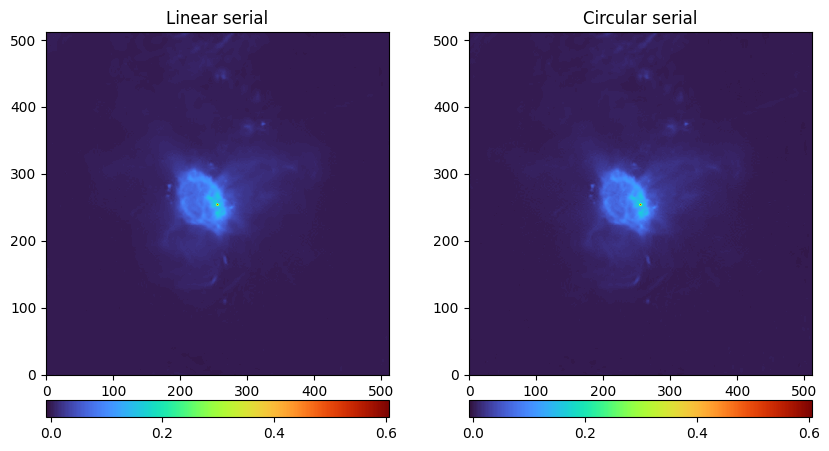

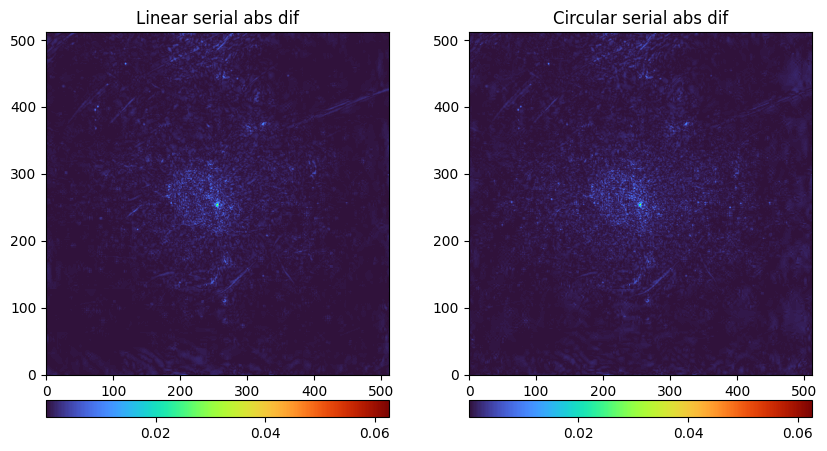

In [33]:
helpers.plotNImages([best_parallel_lin_recon, best_parallel_circ_recon], ["Linear parallel", "Circular parallel"], cmap=cmap, same_scale=True)
helpers.plotNImages([numpy.abs(best_parallel_lin_recon - gt), numpy.abs(best_parallel_circ_recon - gt)], ["Linear parallel abs dif", "Circular parallel abs dif"], cmap=cmap, same_scale=True)

helpers.plotNImages([best_serial_lin_recon, best_serial_circ_recon], ["Linear serial", "Circular serial"], cmap=cmap, same_scale=True)
helpers.plotNImages([numpy.abs(best_serial_lin_recon - gt), numpy.abs(best_serial_circ_recon - gt)], ["Linear serial abs dif", "Circular serial abs dif"], cmap=cmap, same_scale=True)